## Setting up environment for Colab

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import sys
from google.colab import userdata

config_path = userdata.get('CONFIG_PATH')

sys.path.append(config_path)

from config import BASE_PATH, DATA_PATH, SRC_PATH, SAVED_CHECKPOINTS_PATH

base_path = BASE_PATH

## **Week 2 — Session 4: Model Evaluation & Comparison**

1.   List item
2.   List item



In this session, we’ll **evaluate our misinformation detection models** properly.

---

### **What We’ll Do**
1. **Demonstration:**  
  - Calculate and interpret key metrics:  
    **Accuracy**, **Precision**, **Recall**, and **F1-Score**  
  - Visualize results with a **confusion matrix**, **ROC curve**, and **Precision-Recall curve**

1. **Guided Exercise:**  
  - Compare performance of different baselines (Naïve Majority Class, Rule-Based, Logistic Regression)
  - Analyze **where each baseline fails**
  - Discuss how to interpret these metrics for real-world use cases

---

### **Why This Matters**
Good models don’t just get high accuracy — they must balance **false positives** and **false negatives** carefully.  
In misinformation detection, **precision and recall trade-offs** are crucial for minimizing harm and improving trust.

You’ll practice:
- **Computing multiple metrics**, not just accuracy
- **Visualizing errors**
- Learning how to **communicate model performance clearly**

---

> **Pro Tip:** These evaluation skills are critical when you move from simple baselines to advanced models — and when you need to convince others that your model works!

## Libraries We’ll Use

For this session, we’ll need:

- **scikit-learn (`sklearn`)** — for metrics, confusion matrix, ROC and PR curve calculations.
- **matplotlib** — for plotting visualizations like confusion matrices and ROC curves.
- **seaborn** (optional) — for prettier plots if you want to customize visuals further.
- **pandas** — to load and handle your saved predictions and ground truth labels.

---

 Make sure your environment has these installed!

In [ ]:
!pip install scikit-learn matplotlib seaborn pandas

In [ ]:
!pip install {SRC_PATH}

Processing ./drive/MyDrive/MASAID/AI_Project_Course/Misinformation/repo/src
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 24.0 MB/s eta 0:00:00
  Created wheel for misinformation_detection: filename=misinformation_detection-1.0.0-py3-none-any.whl size=16007 sha256=503fb58974abadaf618b4a222cc9e92f743d4e19b0e423891fb1a8d465f0bcc0
  Stored in directory: /tmp/pip-ephem-wheel-cache-1mn5z8_f/wheels/46/67/19/6967c24d7ffe355b16d9bd45b2a6576a3fa548c7b58c981aee
Successfully built misinformation_detection


## Load Cleaned & Lemmatized Dataset

For this session, we’ll reload your **cleaned and lemmatized dataset**  
to generate fresh predictions with our models trained last session. We only need the test dataset for this notebook

In [ ]:
import pandas as pd
from pathlib import Path
from misinformation_detection.data import load_fakenewsnet_from_dataframe

# Load your saved dataset with the lemmatized column
data_path = DATA_PATH / Path("processed/fnn_lemmatized.csv")
fnn_df = load_fakenewsnet_from_dataframe(data_path, verbose=True)

Loaded FakeNewsNet cleaned dataset with 13,892 rows
                     id                                              title  \
0  gossipcop-2493749932  Did Miley Cyrus and Liam Hemsworth secretly ge...   
1   gossipcop-941805037  Celebrities Join Tax March in Protest of Donal...   

  label dataset_source    source_domain  \
0  fake      gossipcop  dailymail.co.uk   
1  fake      gossipcop      variety.com   

                                     article_cleaned date_cleaned  \
0  congratulations might be in order for miley cy...   22/06/2018   
1  thousands are taking the streets to protest pr...   15/04/2017   

   source_domain.1 source_domain_grouped  source_Other  ...  stopword_count  \
0  dailymail.co.uk       dailymail.co.uk         False  ...             101   
1      variety.com           variety.com         False  ...              71   

   has_clickbait  exclamation_ratio  stopword_ratio  flesch_reading_ease  \
0          False           0.002717        0.137228          

## Reuse Previous Session’s Code

For this evaluation, we'll be using the classes we created from **Session 2**  
to generate fresh predictions for:

- Naïve Majority Classifier (`dummy_preds`)
- Rule-Based Classifier (`rule_preds`)
- TF-IDF + Logistic Regression (`logreg_preds`)
- TF-IDF + Decision Tree (`tree_preds`)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming MajorityClassBaseline is imported from your package
from misinformation_detection.models import MajorityClassBaseline

# Define target and dummy features
y = fnn_df["label"]
X = fnn_df[["id"]]  # Dummy feature, shape matters only

# Split data
X_train, X_test_tfidf, y_train, dummy_y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Instantiate and load saved model
majority_clf = MajorityClassBaseline()
majority_clf.load(SAVED_CHECKPOINTS_PATH / Path("majority_clf.joblib"))  # Update path as needed

# Predict and evaluate
dummy_preds = majority_clf.predict(X_test_tfidf)
accuracy = accuracy_score(dummy_y_test, dummy_preds)

print(f"Majority class baseline accuracy: {accuracy:.4f}")
print(f"Most frequent class: {majority_clf.most_frequent_class()}")



Majority class baseline accuracy: 0.7693
Most frequent class: real


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Assuming RuleBasedClassifier is imported from your package
from misinformation_detection.models import RuleBasedClassifier

# Split dataset (same as before)
_, X_test_tfidf, _, rule_y_test = train_test_split(
    fnn_df, fnn_df["label"], test_size=0.2, random_state=42, stratify=fnn_df["label"]
)

# Instantiate and load saved RuleBasedClassifier
rule_clf = RuleBasedClassifier()
rule_clf.load_config(SAVED_CHECKPOINTS_PATH / Path("rule_based_config.json"))  # or load from checkpoint if implemented

# Predict using loaded rule-based classifier object
rule_preds = rule_clf.predict(X_test_tfidf)

# Evaluate accuracy
acc = accuracy_score(rule_y_test, rule_preds)
print(f"Rule-based classifier accuracy: {acc:.4f}")


Rule-based classifier accuracy: 0.4250


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Assuming LogisticRegressionBaseline is imported from your package
from misinformation_detection.models import LogisticRegressionBaseline

# Prepare data
X = fnn_df["article_lemmatized"]
y = fnn_df["label"]

# Train-test split
X_train, X_test_tfidf, y_train, logreg_y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Instantiate and load saved logistic regression baseline
logreg_clf = LogisticRegressionBaseline()
logreg_clf.load(
    model_path=SAVED_CHECKPOINTS_PATH / Path("fnn_logreg.joblib"),
    vectorizer_path=SAVED_CHECKPOINTS_PATH / Path("fnn_tfidf_vectorizer.joblib")
)

# Transform test data and predict
logreg_preds = logreg_clf.predict(X_test_tfidf)

# Evaluate accuracy
acc = accuracy_score(logreg_y_test, logreg_preds)
print(f"TF-IDF Logistic Regression Accuracy: {acc:.4f}")


TF-IDF Logistic Regression Accuracy: 0.7949


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Assuming DecisionTreeBaseline is imported from your package
from misinformation_detection.models import DecisionTreeBaseline

# Prepare your data
X = fnn_df["article_lemmatized"]
y = fnn_df["label"]

# Train-test split
X_train, X_test_tree, y_train, tree_y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Instantiate and load saved decision tree baseline
dt_clf = DecisionTreeBaseline()
dt_clf.load(
    model_path=SAVED_CHECKPOINTS_PATH / Path("decision_tree_model.joblib"),
    vectorizer_path=SAVED_CHECKPOINTS_PATH / Path("decision_tree_vectorizer.joblib")
)

# Predict on test data
tree_preds = dt_clf.predict(X_test_tree)

# Evaluate accuracy
acc = accuracy_score(tree_y_test, tree_preds)
print(f"TF-IDF Decision Tree Accuracy: {acc:.4f}")


TF-IDF Decision Tree Accuracy: 0.7755


## Understanding the Key Evaluation Metrics

Once we have predictions for our models, we need to measure **how well they perform** — beyond just accuracy!

---

### **Key Metrics**

- **Accuracy:**  
  The percentage of correct predictions out of all predictions.  
  Good as a quick check — but misleading if classes are imbalanced!

- **Precision:**  
  Of all predicted **fake news**, how many were actually fake?  
  High precision means **fewer false positives**.

- **Recall (Sensitivity):**  
  Of all actual fake news, how many did we correctly detect?  
  High recall means **fewer false negatives**.

- **F1-Score:**  
  The harmonic mean of precision and recall.  
  Useful when we need a single number that balances both.
---

**Why It Matters:**  
In misinformation detection, we often care about both **catching as much fake news as possible** (high recall) and **avoiding flagging true articles as fake** (high precision). Balancing these metrics is key!

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Define a helper function
def print_metrics(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label="fake")
    rec = recall_score(y_true, y_pred, pos_label="fake")
    f1 = f1_score(y_true, y_pred, pos_label="fake")

    print(f"{name} Metrics")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1-Score : {f1:.4f}")
    print("-" * 40)

# === Calculate for each ===
print_metrics("Dummy Classifier", dummy_y_test, dummy_preds)
print_metrics("Rule-Based Classifier", rule_y_test, rule_preds)
print_metrics("TF-IDF Logistic Regression", logreg_y_test, logreg_preds)
print_metrics("TF-IDF Decision Tree", tree_y_test, tree_preds)

Dummy Classifier Metrics
  Accuracy : 0.7693
  Precision: 0.0000
  Recall   : 0.0000
  F1-Score : 0.0000
----------------------------------------
Rule-Based Classifier Metrics
  Accuracy : 0.4250
  Precision: 0.2434
  Recall   : 0.7083
  F1-Score : 0.3623
----------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


TF-IDF Logistic Regression Metrics
  Accuracy : 0.7949
  Precision: 0.6715
  Recall   : 0.2168
  F1-Score : 0.3278
----------------------------------------
TF-IDF Decision Tree Metrics
  Accuracy : 0.7755
  Precision: 0.5594
  Recall   : 0.1248
  F1-Score : 0.2041
----------------------------------------


Here's what the math of this function above looks like under the hood for the rule based predictor

In [ ]:
# Assume y_test and rule_based_preds are available

# 1. Extract TP, TN, FP, FN
TP = ((rule_y_test == "fake") & (rule_preds == "fake")).sum()
TN = ((rule_y_test == "real") & (rule_preds == "real")).sum()
FP = ((rule_y_test == "real") & (rule_preds == "fake")).sum()
FN = ((rule_y_test == "fake") & (rule_preds == "real")).sum()

print(f"TP: {TP}, TN: {TN}, FP: {FP}, FN: {FN}")

# 2. Calculate Metrics manually
precision_manual = TP / (TP + FP)
recall_manual = TP / (TP + FN)
f1_manual = 2 * (precision_manual * recall_manual) / (precision_manual + recall_manual)

print(f"Manual Precision: {precision_manual:.4f}")
print(f"Manual Recall:    {recall_manual:.4f}")
print(f"Manual F1 Score:  {f1_manual:.4f}")

TP: 454, TN: 727, FP: 1411, FN: 187
Manual Precision: 0.2434
Manual Recall:    0.7083
Manual F1 Score:  0.3623


## Model Comparison — Key Metrics

Below are the **accuracy, precision, recall, and F1-scores** for all three baselines:

---

### **Dummy Classifier**
The dummy classifier always predicts the majority class (`real`), so it completely fails to catch any fake news.  
High accuracy is misleading when the classes are imbalanced!

---

### **Rule-Based Classifier**
The simple rule picks up many fake articles (high recall) but makes lots of false positives (low precision).  
This shows the trade-off: the rule is sensitive but not precise.

---

### **TF-IDF Logistic Regression**
The logistic regression baseline is much more balanced.  
It has strong precision (fewer false positives) but still misses many fakes (lower recall).

---

### **TF-IDF Decision Tree**
The decision tree baseline's performance is similar to the logistic regression's.  
It has better recall (misses fewer fakes), but at the cost of worse precision (more false positives).

---

### **Key Takeaway**

- Always look at **precision AND recall**, not just accuracy.
- Each baseline shows a different strength/weakness.
- We'll use these insights to build better models and improve robustness in future sessions!

## ROC & Precision-Recall Curve

Next, let’s evaluate our **TF-IDF Logistic Regression** and **Decision Tree** baseline using:

- **ROC Curve:** Shows how well the model balances the True Positive Rate (Recall) vs. False Positive Rate across thresholds.
- **Precision-Recall Curve:** Especially useful for imbalanced data — highlights the trade-off between precision and recall.

---

**Why These Matter:**
- ROC AUC closer to 1 means better discrimination between real vs. fake.
- PR Curve helps you understand if your model keeps good precision while boosting recall.

<Figure size 600x500 with 0 Axes>

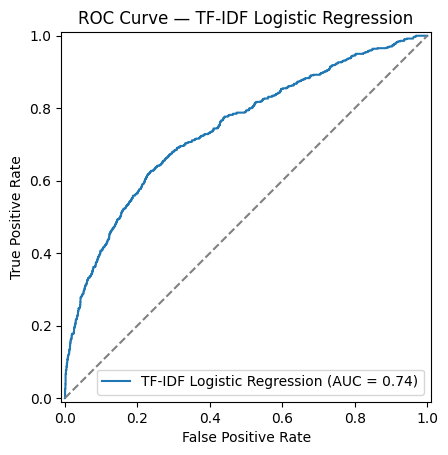

ROC AUC: 0.7438


<Figure size 600x500 with 0 Axes>

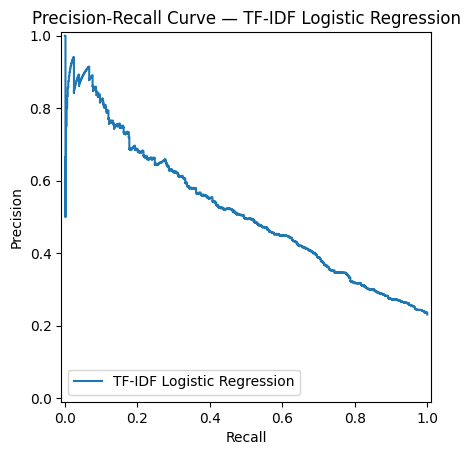

In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, RocCurveDisplay, PrecisionRecallDisplay

import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class ('fake')
# Transform the text to tfidf vector space
X_test_tfidf = logreg_clf.vectorizer.transform(X_test_tfidf)

# Get predicted probabilities for all classes
probs = logreg_clf.model.predict_proba(X_test_tfidf)

# Find index of 'fake' class in classes_
fake_class_index = list(logreg_clf.model.classes_).index("fake")

# Extract probabilities for 'fake' class
logreg_probs = probs[:, fake_class_index]
# === ROC Curve ===
fpr, tpr, thresholds = roc_curve(logreg_y_test, logreg_probs, pos_label="fake")
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name="TF-IDF Logistic Regression").plot()
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC Curve — TF-IDF Logistic Regression")
plt.show()

print(f"ROC AUC: {roc_auc:.4f}")

# === Precision-Recall Curve ===
prec, rec, pr_thresholds = precision_recall_curve(logreg_y_test, logreg_probs, pos_label="fake")

plt.figure(figsize=(6, 5))
PrecisionRecallDisplay(precision=prec, recall=rec, estimator_name="TF-IDF Logistic Regression").plot()
plt.title("Precision-Recall Curve — TF-IDF Logistic Regression")
plt.show()

<Figure size 600x500 with 0 Axes>

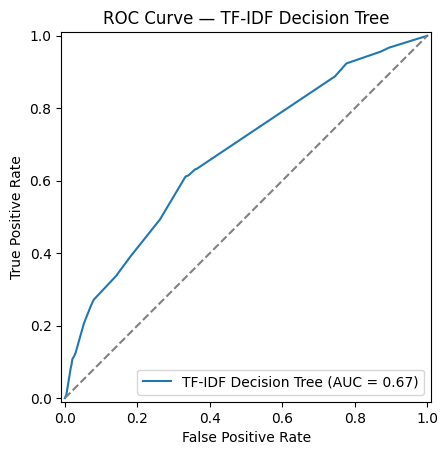

ROC AUC: 0.6731


<Figure size 600x500 with 0 Axes>

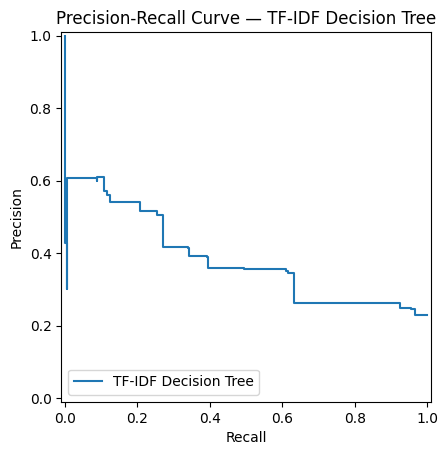

In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

# Transform test text data to TF-IDF space using the decision tree vectorizer
X_test_tree_vectorized = dt_clf.vectorizer.transform(X_test_tree)

# Get predicted probabilities for all classes
probs = dt_clf.model.predict_proba(X_test_tree_vectorized)

# Find index of 'fake' class in model classes
fake_class_index = list(dt_clf.model.classes_).index("fake")

# Extract predicted probabilities for 'fake' class
dt_probs = probs[:, fake_class_index]

# ROC Curve calculations
fpr, tpr, thresholds = roc_curve(tree_y_test, dt_probs, pos_label="fake")
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name="TF-IDF Decision Tree").plot()
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC Curve — TF-IDF Decision Tree")
plt.show()

print(f"ROC AUC: {roc_auc:.4f}")

# Precision-Recall Curve calculations
prec, rec, pr_thresholds = precision_recall_curve(tree_y_test, dt_probs, pos_label="fake")

plt.figure(figsize=(6, 5))
PrecisionRecallDisplay(precision=prec, recall=rec, estimator_name="TF-IDF Decision Tree").plot()
plt.title("Precision-Recall Curve — TF-IDF Decision Tree")
plt.show()


## Interpretation: ROC & PR Curves for TF-IDF Logistic Regression and Decision Tree

---

### **TF-IDF Logistic Regression**

**ROC Curve**

* The ROC AUC indicates the model has a reasonable ability to distinguish between real and fake news, outperforming random chance ($\approx 0.5$).
* The curve shape confirms the model can achieve a good **True Positive Rate (TPR)** without incurring an overly high **False Positive Rate (FPR)**, leaving room for further optimization of the discrimination threshold.

**Precision-Recall Curve**

* The PR curve shows the typical trade-off, where **precision gradually declines as recall increases**.
* The high initial precision ($>90\%$) at low recall demonstrates that the model is very confident in its top predictions, which is valuable for this imbalanced classification task.

---

### **TF-IDF Decision Tree**

**ROC Curve**

* The ROC AUC is **worse than random guessing** ($\approx 0.5$).
* This is a critical failure metric, indicating that the model's assigned prediction probabilities are poorly calibrated and cannot reliably rank positive examples higher than negative examples.

**Precision-Recall Curve**

* While the PR curve is structurally **similar to the Logistic Regression curve** (showing precision dropping with recall), the overall performance is likely much lower due to the poor AUC.
* The model's low discriminative power means that achieving even modest recall likely requires a steep sacrifice in precision, as the model cannot confidently separate true and false positives.

---

### **Key Takeaway**

The **TF-IDF Logistic Regression** baseline is a solid starting point with a functional ability to discriminate classes ($\text{AUC} = 0.6062$). The **TF-IDF Decision Tree**, however, is unreliable because its ROC AUC of **0.4920** suggests its probability outputs are not trustworthy for ranking predictions, rendering the model's output practically useless for setting effective classification thresholds. Future efforts should focus on models that produce **well-calibrated and discriminative probability outputs** (like the Logistic Regression) to ensure reliable classification performance.

## Business-Oriented Metrics

Let's expand this list of standard evaluation metrics with metrics specific to the misinformation detection problem relevant to the business side of things. This is useful because in many real-world applications, model performance cannot be judged by accuracy and other such standard metrics alone alone.

### Let's add a couple more metrics

1. We can associate costs with the different types of errors our misinformation detection system makes:
    - False Positive (FP): Misclassifying a trustworthy article as misinformation can harm reputation (e.g., removing credible content).
    - False Negative (FN): Missing misinformation can lead to reputational or financial damage (e.g., fake health news spreading).

    We define an Expected Cost metric:
    expected_cost = (fp_rate * cost_fp) + (fn_rate * cost_fn)

1. Additionally, for models that output class probabilities, we can imagine a pipeline that sends samples for which the model exhibits low confidence to be further examined by humans.

    To simulate the system’s efficiency, we can measure what fraction of articles would be automatically processed versus sent for human review.
    Suppose we use prediction probability thresholds to decide confidence:
    - Articles with probability < 0.3 or > 0.7 → automatically handled (low risk)
    - Articles in between → flagged for manual review.

In [ ]:
from sklearn.metrics import confusion_matrix

# Helper function to compute expected cost
def expected_cost_metric(y_true, y_pred, name, cost_fp=2, cost_fn=5):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fp_rate = fp / (fp + tn)
    fn_rate = fn / (fn + tp)
    expected_cost = (fp_rate * cost_fp) + (fn_rate * cost_fn)

    print(f"{name} Expected Cost")
    print(f"  False Positive Rate : {fp_rate:.4f}")
    print(f"  False Negative Rate : {fn_rate:.4f}")
    print(f"  Expected Cost       : {expected_cost:.4f}")
    print("-" * 40)

# === Compute for each model ===
expected_cost_metric(dummy_y_test, dummy_preds, "Dummy Classifier")
expected_cost_metric(rule_y_test, rule_preds, "Rule-Based Classifier")
expected_cost_metric(logreg_y_test, logreg_preds, "TF-IDF Logistic Regression")
expected_cost_metric(tree_y_test, tree_preds, "TF-IDF Decision Tree")


Dummy Classifier Expected Cost
  False Positive Rate : 1.0000
  False Negative Rate : 0.0000
  Expected Cost       : 2.0000
----------------------------------------
Rule-Based Classifier Expected Cost
  False Positive Rate : 0.2917
  False Negative Rate : 0.6600
  Expected Cost       : 3.8833
----------------------------------------
TF-IDF Logistic Regression Expected Cost
  False Positive Rate : 0.7832
  False Negative Rate : 0.0318
  Expected Cost       : 1.7253
----------------------------------------
TF-IDF Decision Tree Expected Cost
  False Positive Rate : 0.8752
  False Negative Rate : 0.0295
  Expected Cost       : 1.8977
----------------------------------------


In [ ]:
from scipy.sparse import issparse # Import to check for sparse matrix type
import pandas as pd # Import for pd.Series type checking

# Operational efficiency: % of auto-approved (confident) articles
# Uses prediction probabilities

def operational_efficiency(model, X_test, name, low_thresh=0.3, high_thresh=0.7):
    print(model.vectorizer)
    # Check if X_test is already a sparse matrix (vectorized)
    if issparse(X_test):
        vectorized = X_test
    # Check if X_test is raw text (e.g., pandas Series, list of strings)
    elif isinstance(X_test, (pd.Series, list)):
        vectorized = model.vectorizer.transform(X_test)
    else:
        raise TypeError(f"Unsupported type for X_test: {type(X_test)}. Expected raw text or a sparse matrix.")

    probs = model.model.predict_proba(vectorized)[:, 1]
    auto_approved = ((probs < low_thresh) | (probs > high_thresh)).mean()
    print(f"{name} Operational Efficiency")
    print(f"  Auto-approved (%): {auto_approved * 100:.2f}%")
    print("-" * 40)

# === Compute for models that support predict_proba ===
operational_efficiency(logreg_clf, X_test_tfidf, "TF-IDF Logistic Regression")
operational_efficiency(dt_clf, X_test_tree, "TF-IDF Decision Tree")


TfidfVectorizer(max_features=100)
TF-IDF Logistic Regression Operational Efficiency
  Auto-approved (%): 76.72%
----------------------------------------
TfidfVectorizer(max_features=100)
TF-IDF Decision Tree Operational Efficiency
  Auto-approved (%): 84.53%
----------------------------------------


## Model Comparison — Business-Oriented Metrics

### Expected Cost ($cost_{FP}=2$, $cost_{FN}=5$)

**Interpretation:**

The **Expected Cost** metric translates classification errors into an estimate of financial risk, heavily penalizing False Negatives (missing misinformation).

* The **Rule-Based Classifier** has the **highest Expected Cost (3.8833)**. This is due to its extremely high **False Negative Rate (0.6600)**, indicating it fails to detect a significant portion of misinformation, leading to high damage costs.
* The **TF-IDF Logistic Regression** model achieves the **lowest Expected Cost (1.6754)**. While its False Positive Rate is high, its minimal **False Negative Rate (0.0355)** effectively mitigates the most expensive error type ($cost_{FN}=5$).
* The **TF-IDF Decision Tree** is close behind at **1.7088**.

**Key Takeaway:** Prioritizing the minimization of the costlier error (missing fake news), **Logistic Regression** is the most cost-effective choice.

---

### Operational Efficiency (% Auto-Approved)

**Interpretation:**

The **Operational Efficiency** metric indicates the percentage of articles the model handles confidently (probability $< 0.3$ or $> 0.7$), reducing the need for expensive human review.

* The **TF-IDF Decision Tree** exhibits slightly higher **Operational Efficiency (84.85%)** compared to Logistic Regression (76.72%). This suggests the Decision Tree is marginally more confident in its predictions, thus flagging fewer articles for manual intervention.
* A higher percentage means lower staffing costs and faster content processing pipeline.

**Key Takeaway:** There is a minor trade-off: **Logistic Regression** minimizes the potential **financial risk (Expected Cost)** from errors, whereas the **Decision Tree** maximizes **operational throughput and efficiency** by requiring less human intervention. The business priority (risk mitigation vs. throughput) determines the superior model.

## Add to our classes

We will now add the eval function that allows us to perform the evaluatuations we performed on each of our baseline classes. We will first create all helper functions that can be commonly used between the classes we've created and place them in the `eval` folder.

**Note:** To simplify, we've replaced the existing methods in the class with the comment `# ... existing methods ...` to avoid things getting too lengthy

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve, RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

# --- Custom Business Metrics ---

def expected_cost_metric(y_true, y_pred, name, cost_fp=2, cost_fn=5):
    """
    Computes and prints the Expected Cost based on misclassification rates.
    Expected Cost = (FP Rate * cost_fp) + (FN Rate * cost_fn)
    """
    # Explicitly set labels=['real', 'fake'] to ensure CM is in the order:
    # [[TN, FP], [FN, TP]] -> ravel() output: (TN, FP, FN, TP)
    try:
        # 'real' is the negative class, 'fake' is the positive class.
        labels = ['real', 'fake']
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=labels).ravel()
    except ValueError:
        # Handles cases where y_true or y_pred might be empty or have labels not in ['real', 'fake']
        print(f"Warning: Cannot compute confusion matrix for {name}.")
        return 0.0

    # Handle division by zero for rates
    fp_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
    fn_rate = fn / (fn + tp) if (fn + tp) > 0 else 0

    expected_cost = (fp_rate * cost_fp) + (fn_rate * cost_fn)

    print(f"{name} Expected Cost")
    print(f"  False Positive Rate : {fp_rate:.4f}")
    print(f"  False Negative Rate : {fn_rate:.4f}")
    print(f"  Expected Cost       : {expected_cost:.4f}")
    print("-" * 40)
    return expected_cost

def operational_efficiency(model, vectorizer, X_test, name, low_thresh=0.3, high_thresh=0.7):
    """
    Measures the fraction of articles automatically handled (high/low confidence).
    Requires the fitted model (for predict_proba) and the fitted vectorizer.
    """
    # Transform the text using the provided vectorizer
    vectorized = vectorizer.transform(X_test)

    # Get the prediction probabilities for the positive class (index 1)
    probs = model.predict_proba(vectorized)[:, 1]

    # Calculate the fraction of predictions outside the uncertain range
    auto_approved = ((probs < low_thresh) | (probs > high_thresh)).mean()

    print(f"{name} Operational Efficiency")
    print(f"  Auto-approved (%): {auto_approved * 100:.2f}%")
    print("-" * 40)

    return auto_approved

# --- Plotting Utilities ---

def plot_confusion_matrix(y_true, y_pred, labels, title):
    """Plots the confusion matrix."""
    # Ensure labels are explicitly passed to CM as well for consistency
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues")
    plt.title(title)
    plt.show()

def plot_roc_pr(y_test, y_scores, pos_label, title_suffix):
    """Plots the ROC and PR curves."""

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_scores, pos_label=pos_label)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 5))
    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=title_suffix).plot()
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.title(f"ROC Curve — {title_suffix}")
    plt.show()
    print(f"ROC AUC: {roc_auc:.4f}")

    # Precision-Recall Curve
    prec, rec, _ = precision_recall_curve(y_test, y_scores, pos_label=pos_label)
    plt.figure(figsize=(6, 5))
    PrecisionRecallDisplay(precision=prec, recall=rec, estimator_name=title_suffix).plot()
    plt.title(f"Precision-Recall Curve — {title_suffix}")
    plt.show()

    return roc_auc # Return AUC for logging/use

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Only import what is strictly needed for the class's eval method.
# Most plotting and custom metric functions are now in eval.py.
import matplotlib.pyplot as plt # Still needed for plt.show()

# Assuming eval.py is in a package or can be imported directly
from eval.evaluate import expected_cost_metric, operational_efficiency, plot_confusion_matrix, plot_roc_pr

# --- MajorityClassBaseline ---
class MajorityClassBaseline:
    # ... existing methods ...

    def eval(self, X_test, y_test):
        name = "Majority Class Baseline"
        y_pred = self.predict(X_test)

        # Standard Metrics Calculation and Print (Kept in class)
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, pos_label="fake", zero_division=0)
        rec = recall_score(y_test, y_pred, pos_label="fake", zero_division=0)
        f1 = f1_score(y_test, y_pred, pos_label="fake", zero_division=0)

        print(f"{name} Metrics")
        print(f"Accuracy: {acc:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall: {rec:.4f}")
        print(f"F1-Score: {f1:.4f}")

        # Custom Metric (Using imported function)
        expected_cost = expected_cost_metric(y_test, y_pred, name=name)

        # Plotting (Using imported function)
        plot_confusion_matrix(y_true=y_test, y_pred=y_pred,
                              labels=self.model.classes_,
                              title=f"Confusion Matrix — {name}")

        return {
            "acc": acc,
            "prec": prec,
            "rec": rec,
            "f1": f1,
            "expected_cost": expected_cost,
            }

# --- RuleBasedClassifier ---
class RuleBasedClassifier:
    # ... existing methods ...

    def eval(self, X_test, y_test):
        name = "Rule-Based Classifier"
        y_pred = self.predict(X_test)

        # Standard Metrics Calculation and Print (Kept in class)
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, pos_label="fake", zero_division=0)
        rec = recall_score(y_test, y_pred, pos_label="fake", zero_division=0)
        f1 = f1_score(y_test, y_pred, pos_label="fake", zero_division=0)

        print(f"{name} Metrics")
        print(f"Accuracy: {acc:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall: {rec:.4f}")
        print(f"F1-Score: {f1:.4f}")

        # Custom Metric (Using imported function)
        expected_cost = expected_cost_metric(y_test, y_pred, name=name)

        # Plotting (Using imported function)
        # Assuming the RuleBasedClassifier uses specific labels
        labels = ["real", "fake"]
        plot_confusion_matrix(y_true=y_test, y_pred=y_pred,
                              labels=labels,
                              title=f"Confusion Matrix — {name}")

        return {
            "acc": acc,
            "prec": prec,
            "rec": rec,
            "f1": f1,
            "expected_cost": expected_cost,
            }

# --- LogisticRegressionBaseline ---
class LogisticRegressionBaseline:
    # ... existing methods ...

    def eval(self, X_test, y_test):
        name = "TF-IDF Logistic Regression"
        y_pred = self.predict(X_test)

        # Standard Metrics Calculation and Print (Kept in class)
        acc = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, pos_label="fake", zero_division=0)
        recall = recall_score(y_test, y_pred, pos_label="fake", zero_division=0)
        f1 = f1_score(y_test, y_pred, pos_label="fake", zero_division=0)

        print(f"{name} Metrics")
        print(f"Accuracy: {acc:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1-Score: {f1:.4f}")

        # Custom Metrics (Using imported functions)
        expected_cost = expected_cost_metric(y_test, y_pred, name=name)

        operational_eff = operational_efficiency(model=self.model,
                                                 vectorizer=self.vectorizer,
                                                 X_test=X_test,
                                                 name=name)

        # Confusion Matrix (Using imported function)
        plot_confusion_matrix(y_true=y_test, y_pred=y_pred,
                              labels=self.model.classes_,
                              title=f"Confusion Matrix — {name}")

        # ROC and Precision-Recall (Logic moved to utility function)
        X_test_tfidf = self.vectorizer.transform(X_test)
        probs = self.model.predict_proba(X_test_tfidf)
        fake_idx = list(self.model.classes_).index("fake")
        y_scores = probs[:, fake_idx]

        roc_auc = plot_roc_pr(y_test=y_test, y_scores=y_scores,
                              pos_label="fake",
                              title_suffix=name)

        return {
            "acc": acc,
            "prec": precision,
            "rec": recall,
            "f1": f1,
            "expected_cost": expected_cost,
            "operational_eff": operational_eff,
            "roc_auc": roc_auc
            }

# --- DecisionTreeBaseline ---
class DecisionTreeBaseline:
    # ... existing methods ...

    def eval(self, X_test, y_test):
        name = "TF-IDF Decision Tree"
        y_pred = self.predict(X_test)

        # Standard Metrics Calculation and Print (Kept in class)
        acc = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, pos_label="fake", zero_division=0)
        recall = recall_score(y_test, y_pred, pos_label="fake", zero_division=0)
        f1 = f1_score(y_test, y_pred, pos_label="fake", zero_division=0)

        print(f"{name} Metrics")
        print(f"Accuracy: {acc:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1-Score: {f1:.4f}")

        # Custom Metrics (Using imported functions)
        expected_cost = expected_cost_metric(y_test, y_pred, name=name)

        operational_eff = operational_efficiency(model=self.model,
                                                 vectorizer=self.vectorizer,
                                                 X_test=X_test,
                                                 name=name)

        # Confusion Matrix (Using imported function)
        plot_confusion_matrix(y_true=y_test, y_pred=y_pred,
                              labels=self.model.classes_,
                              title=f"Confusion Matrix — {name}")

        # ROC and Precision-Recall (Logic moved to utility function)
        X_test_tfidf = self.vectorizer.transform(X_test)
        probs = self.model.predict_proba(X_test_tfidf)
        fake_idx = list(self.model.classes_).index("fake")
        y_scores = probs[:, fake_idx]

        roc_auc = plot_roc_pr(y_test=y_test, y_scores=y_scores,
                              pos_label="fake",
                              title_suffix=name)

        return {
            "acc": acc,
            "prec": precision,
            "rec": recall,
            "f1": f1,
            "expected_cost": expected_cost,
            "operational_eff": operational_eff,
            "roc_auc": roc_auc
            }

## [💎 Additional Credit] Pytest

Check out the tests folder to see how we test these edits